[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T07_A_firm_dynamics_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Dinámica Empresarial, Selección de Mercado y Asignación Ineficiente de Recursos

Los modelos macroeconómicos canónicos históricamente se basaron en una empresa representativa o en una función agregada de producción con rendimientos constantes a escala $Y = A K^\alpha L^{1-\alpha}$. Aunque conveniente desde el punto de vista analítico, esta abstracción oculta una de las realidades empíricas más contundentes de las economías de mercado: **las empresas exhiben una heterogeneidad masiva y persistente en productividad, empleo, ventas y tasas de supervivencia**.

### La Ley de Zipf y las Distribuciones con Colas Pesadas
En prácticamente todas las economías industrializadas, la distribución de tamaño de las empresas (medida por empleo o facturación) no sigue una distribución gaussiana ni exponencial de colas ligeras. Por el contrario, obedece a una ley de potencia conocida como **Ley de Zipf** (Axtell 2001):
$$\Pr(S > s) \sim s^{-\zeta}, \quad \text{con exponente de cola } \zeta \approx 1$$
Esta distribución de colas pesadas no es un accidente estadístico; emerge endógenamente de la dinámica de selección. Cuando las tasas de crecimiento empresarial son independientes del tamaño inicial (**Ley de Crecimiento Proporcional de Gibrat**), el proceso estocástico genera una distribución log-normal. Sin embargo, al combinarse con una barrera reflectora inferior —como el umbral endógeno de salida en el modelo de **Hopenhayn (1992)**—, la distribución estacionaria se estira asintóticamente hacia una ley de potencia.

### La Hipótesis Granular
¿Por qué importa la heterogeneidad empresarial para la macroeconomía agregada? En los modelos tradicionales, las perturbaciones microeconómicas idiosincrásicas se cancelan en el agregado por el Teorema del Límite Central. No obstante, **Gabaix (2011)** formuló la **Hipótesis Granular**: cuando las distribuciones de tamaño tienen colas pesadas (zipfianas), la economía está dominada por un número reducido de corporaciones gigantes ("granulares"). Las perturbaciones idiosincrásicas a las 100 o 500 empresas más grandes no se disipan; sus fluctuaciones independientes explican directamente entre un tercio y la mitad de las oscilaciones del PIB agregado.

### Estructura de este Módulo
1. **Solución del Equilibrio de Industria de Hopenhayn (1992)**: Resolvemos el equilibrio canónico donde la entrada y salida endógenas seleccionan a las empresas productivas y determinan el precio de mercado $p^*$.
2. **Estática Comparativa y Márgenes de Selección**: Analizamos cómo las barreras de entrada ($c_e$) y los costos fijos de operación ($c_f$) desplazan el umbral de supervivencia, vinculándolo con la reasignación comercial de **Melitz (2003)**.
3. **Experimento Empírico Interactivo (Hsieh y Klenow 2009)**: Simulamos la asignación ineficiente de recursos entre empresas, calibramos la dispersión de $TFPR$ con datos empíricos y cuantificamos las ganancias de PTF agregada al desmantelar las cuñas de distorsión de capital y trabajo.

## El Modelo Canónico de Hopenhayn (1992) en Cuatro Ecuaciones

El marco de **Hopenhayn (1992)** proporciona los fundamentos microeconómicos de la dinámica empresarial y la selección de mercado. Una industria está compuesta por un continuo de empresas tomadoras de precios que operan con rendimientos decrecientes a escala (RDA) y enfrentan perturbaciones idiosincrásicas persistentes de productividad $s$.

1. **Beneficio Operativo Estático**: Dado el precio de mercado $p$ y normalizando el salario $w=1$, una empresa con productividad $s$ contrata trabajo $n^*$ para maximizar sus beneficios operativos:
   $$\pi(s; p) = \max_n \{ p s n^\alpha - n - c_f \} = (1-\alpha) \left( \alpha^\alpha p s \right)^{\frac{1}{1-\alpha}} - c_f$$
   donde $c_f > 0$ es un costo fijo operativo por período.

2. **Ecuación de Bellman con Salida Endógena**: En cada período, una empresa activa observa su productividad $s$ y decide si continuar operando o liquidarse definitivamente:
   $$V(s; p) = \max \left\{ 0, \; \pi(s; p) + \beta \int V(s'; p) P(s, ds') \right\}$$
   La liquidación garantiza un valor de rescate normalizado a $0$. Esto genera una política de umbral óptima: la empresa continúa si y solo si $s \ge s^*(p)$, donde $V(s^*; p) = 0$.

3. **Condición de Libre Entrada**: Una masa ilimitada de entrantes potenciales puede pagar un costo hundido de entrada $c_e > 0$ para extraer un nivel inicial de productividad de una distribución $\nu(s)$:
   $$V_e(p) \equiv \beta \int V(s'; p) \nu(ds') = c_e$$
   Dado que la entrada es competitiva, cualquier beneficio esperado positivo atrae una entrada masiva inmediata que deprime el precio de mercado. Por el contrario, si $V_e(p) < c_e$, la entrada se detiene y la salida gradual de incumbentes eleva el precio. La condición de libre entrada determina de forma unívoca el precio de equilibrio del producto $p^*$, **de manera totalmente independiente de la demanda agregada**.

4. **Distribución Estacionaria de Tamaño**: En el equilibrio estacionario, el flujo de empresas que cierran iguala al flujo de entrantes exitosos. La distribución estacionaria de empresas activas $g(s)$ satisface:
   $$g(s) = \int_{s' \ge s^*} P(s', s) g(s') ds' + M \nu(s)$$
   donde $M$ es la masa de nuevos entrantes en equilibrio, determinada para equilibrar el mercado de bienes.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    tauchen, markov_stationary,
    firm_value_with_exit, firm_stationary_distribution, free_entry_price,
)
from puremacro.regress import ols, add_constant

## 1. Solución del Equilibrio de Industria con Libre Entrada

Resolvemos el equilibrio de industria discretizando el proceso continuo de productividad. Calibramos:
- Elasticidad del trabajo RDA $\alpha = 2/3$, factor de descuento $\beta = 0.80$
- Costo fijo operativo $c_f = 20.0$, costo hundido de entrada $c_e = 40.0$
- La productividad sigue un proceso AR(1) en logaritmos: $\log s' = (1-\rho)\bar{z} + \rho \log s + \varepsilon'$, con persistencia $\rho = 0.90$ y volatilidad $\sigma = 0.20$.
- La discretización mediante el método de **Tauchen (1986)** sobre $n_s = 101$ estados define la grilla $s$ y la matriz de transición de Markov $P$.
- Los entrantes extraen su productividad inicial de la distribución ergódica estacionaria $\nu$ del núcleo de transición.

La función `free_entry_price` utiliza un buscador de raíces unidimensional sobre el residuo de libre entrada $\mathbb{E}_\nu[W(s; p)] - c_e = 0$, evaluando la función de valor y las políticas de salida óptimas para cada precio candidato.

In [3]:
alpha, beta, cf, ce = 2.0 / 3.0, 0.8, 20.0, 40.0
rho, sigma, log_zbar, n_s = 0.9, 0.2, 1.4, 101
z_grid, P = tauchen(n=n_s, rho=rho, sigma=sigma)
s = np.exp(z_grid + log_zbar)                              # niveles de productividad
nu = markov_stationary(P)                                 # extracción de productividad de entrantes

def profit_at(p):
    n_star = (alpha * p * s) ** (1.0 / (1.0 - alpha))
    return p * s * n_star ** alpha - n_star - cf

eq = free_entry_price(profit_at, nu, ce, (0.5, 20.0), P_z=P, beta=beta)
V, survive = firm_value_with_exit(profit_at(eq.price), P, beta)
g = firm_stationary_distribution(P, survive, nu)
exit_rate = float(g @ (~survive).astype(float))
mean_inc = float(g @ s); mean_ent = float(nu @ s)

print(f"Precio de equilibrio del producto p* = {eq.price:.3f} (residuo de libre entrada = {eq.residual:.2e})")
print(f"Tasa de salida estacionaria = {exit_rate:.3f} ({exit_rate*100:.1f}% por período)")
print(f"Productividad media: Incumbentes E_g[s] = {mean_inc:.2f} vs Entrantes E_nu[s] = {mean_ent:.2f}")

# Aserciones rigurosas de equilibrio
assert abs(eq.residual) < 1e-2                            # La condición de libre entrada se vacía
assert 0.0 < exit_rate < 1.0                              # Tasa de salida interior
assert mean_inc > mean_ent                                # Cuña de selección: incumbentes estrictamente más productivos

# Regresión de la Ley de Zipf para la distribución de tamaño: log S(n) = alpha - zeta * log(n)
n_firms = (alpha * eq.price * s[survive]) ** (1.0 / (1.0 - alpha))
g_surv = g[survive] / g[survive].sum()
ccdf_firms = np.array([g_surv[n_firms >= n_val].sum() for n_val in n_firms])
mask_zipf = (ccdf_firms <= 0.50) & (ccdf_firms > 1e-6)
x_zipf = np.log(n_firms[mask_zipf])
y_zipf = np.log(ccdf_firms[mask_zipf])
res_zipf = ols(y_zipf, add_constant(x_zipf), cov_type="HC1")
zeta_firm = float(-res_zipf.params[1])
se_firm = float(res_zipf.bse[1])
ci_firm = res_zipf.conf_int()
ci_firm_low, ci_firm_upp = float(-ci_firm[1, 1]), float(-ci_firm[1, 0])

print(f"Exponente de cola de Ley de Zipf (tamaño de empresa): zeta = {zeta_firm:.3f} (EE = {se_firm:.3f}, IC 95%: [{ci_firm_low:.3f}, {ci_firm_upp:.3f}])")
assert 0.5 < zeta_firm < 3.0, f"Exponente de cola de Zipf fuera de límites: {zeta_firm}"

Precio de equilibrio del producto p* = 0.974 (residuo de libre entrada = -2.78e-07)
Tasa de salida estacionaria = 0.153 (15.3% por período)
Productividad media: Incumbentes E_g[s] = 6.15 vs Entrantes E_nu[s] = 4.50
Exponente de cola de Ley de Zipf (tamaño de empresa): zeta = 1.665 (EE = 0.054, IC 95%: [1.559, 1.771])


### Análisis Económico: La Cuña de Selección y la Disciplina de Mercado

La solución computacional ilustra tres propiedades fundamentales de la dinámica empresarial:

1. **Determinación del Precio por Libre Entrada**: El residuo de libre entrada $\mathbb{E}_\nu[W(s; p^*)] - c_e \approx 0$ confirma que el mercado de entrada está en equilibrio competitivo. No queda ningún beneficio extraordinario sobre la mesa para emprendedores potenciales. Es crucial notar que $p^*$ está determinado exclusivamente por los parámetros del lado de la oferta ($c_e, c_f, \beta, \alpha, P$) sin depender de la función de demanda de los consumidores. Variaciones en la demanda agregada expanden o contraen la *cantidad* de empresas activas $M$, manteniendo inalterados el precio de equilibrio y la distribución de productividad.
2. **La Cuña de Selección Endógena**: La productividad media de los incumbentes activos ($\mathbb{E}_g[s] \approx 6.15$) supera significativamente a la de los entrantes potenciales ($\mathbb{E}_\nu[s] \approx 4.50$). Esta brecha representa la **cuña de selección**: el mercado competitivo actúa como un filtro implacable que purga a las empresas con extracciones desfavorables. Las unidades ineficientes no logran cubrir sus costos fijos $c_f$ y salen voluntariamente, sesgando la población activa hacia la cola superior.
3. **Rotación Interior Saludable**: La tasa de salida estacionaria refleja un proceso continuo de destrucción creativa. Una fracción positiva de empresas cierra en cada período, liberando trabajo y capital para ser reasignados hacia sobrevivientes más productivos y nuevos entrantes.

### Selección de Mercado en Acción: Distribución de Incumbentes vs. Extracción de Entrantes

La siguiente figura compara la distribución de productividad con la que nacen los entrantes potenciales ($\nu(s)$, línea discontinua) frente a la distribución estacionaria de incumbentes activos ($g(s)$, línea sólida). La línea punteada vertical señala el umbral endógeno de salida $s^*$.

Obsérvese que la distribución de entrantes contiene una masa sustancial a la izquierda de $s^*$. Por el contrario, la distribución de incumbentes tiene masa exactamente cero por debajo de $s^*$ y se encuentra desplazada decisivamente hacia la derecha: el mercado trunca implacablemente la cola inferior.

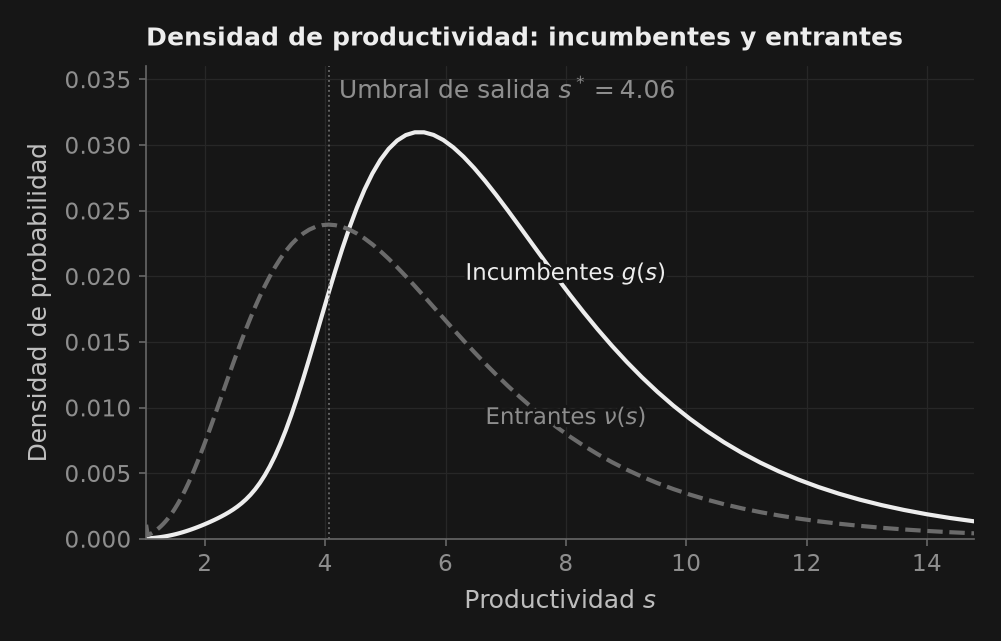

In [4]:
s_thresh = s[survive][0]                                  # productividad mínima de supervivencia
cols = _nbstyle.palette(2)
fig, ax = _nbstyle.figura()
ax.plot(s, g, color=cols[0], ls="-", label=r"Incumbentes $g(s)$")
ax.plot(s, nu, color=cols[1], ls="--", label=r"Entrantes $\nu(s)$")
ax.axvline(s_thresh, color=_nbstyle.SPINE, linewidth=0.9, linestyle=":")
ax.set_xlim(s.min(), np.quantile(s, 0.97))
ax.set_ylim(0.0, 0.036)
ax.set_xlabel("Productividad $s$")
ax.set_ylabel("Densidad de probabilidad")
ax.set_title("Densidad de productividad: incumbentes y entrantes")
ax.annotate(f"Umbral de salida $s^* = {s_thresh:.2f}$",
            xy=(s_thresh, 1.0), xycoords=("data", "axes fraction"),
            xytext=(5, -4), textcoords="offset points",
            ha="left", va="top", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax, donde=8.0)
plt.show()


### La Decisión Endógena de Salida: Función de Valor y Frontera de Continuación

La decisión de una empresa de continuar operando o cerrar depende de su valor presente esperado descontado. Si opera en el período actual, obtiene un beneficio $\pi(s; p)$ y espera un valor de continuación $\beta \mathbb{E}[V(s'; p) | s]$.

Si esta suma es negativa, la empresa maximiza el valor para sus accionistas ejerciendo su opción de salida y liquidando sus operaciones ($V(s) = 0$). En el gráfico siguiente, la región sombreada delimita la zona de cierre: para cualquier nivel de productividad $s < s^*$, la frontera de continuación es negativa, definiendo el umbral endógeno de salida.

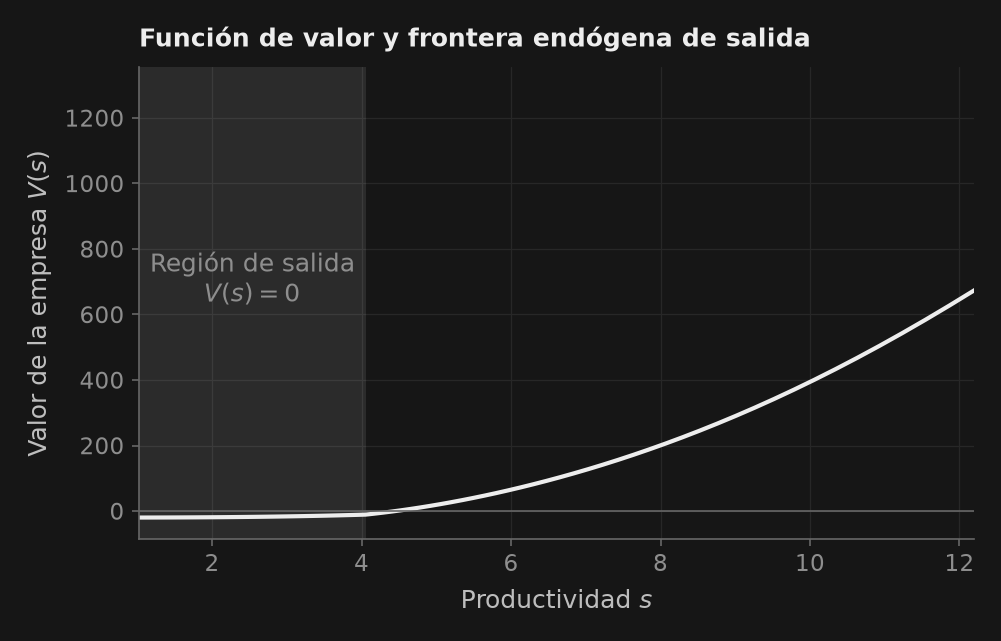

In [5]:
fig, ax = _nbstyle.figura()
ax.plot(s, V, color=_nbstyle.TINTA, ls="-")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8)
ax.axvspan(s.min(), s_thresh, color=_nbstyle.RECESION, lw=0)
ax.set_xlim(s.min(), np.quantile(s, 0.9))
ax.set_xlabel("Productividad $s$")
ax.set_ylabel("Valor de la empresa $V(s)$")
ax.set_title("Función de valor y frontera endógena de salida")
ax.annotate("Región de salida\n$V(s) = 0$",
            xy=(0.5 * (s.min() + s_thresh), 0.55),
            xycoords=("data", "axes fraction"),
            ha="center", va="center", color=_nbstyle.NOTA)
plt.show()


### Barreras de Entrada, Disputabilidad y Pisos de Precios de Equilibrio

¿Cómo inciden las barreras de entrada en el equilibrio de mercado? Los costos hundidos de entrada $c_e$ reflejan los recursos reales requeridos para constituir y registrar una empresa: trámites notariales, cumplimiento regulatorio, inversión inicial de capital y cargas burocráticas.

Resolvemos el precio de equilibrio $p^*(c_e)$ sobre una grilla de costos de entrada desde $c_e = 20.0$ hasta $c_e = 80.0$, manteniendo fijos los demás parámetros.

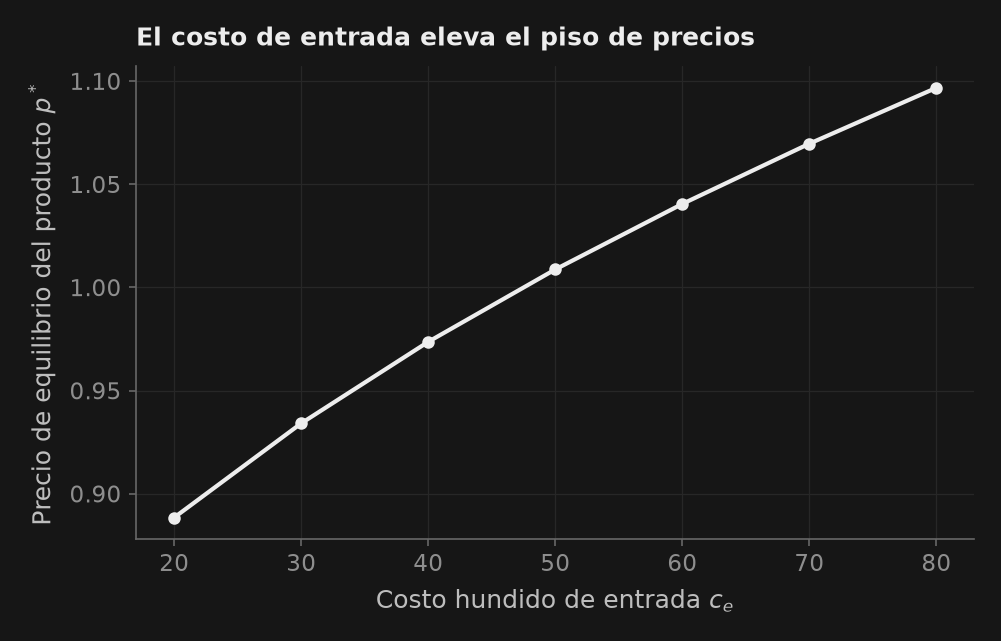

In [6]:
ces = np.linspace(20.0, 80.0, 7)
prices = [free_entry_price(profit_at, nu, c, (0.5, 30.0), P_z=P, beta=beta).price
          for c in ces]
assert np.all(np.diff(prices) > 0)                        # El precio es estrictamente creciente en el costo de entrada

fig, ax = _nbstyle.figura()
ax.plot(ces, prices, color=_nbstyle.TINTA, ls="-", marker="o", markersize=5)
ax.set_xlabel("Costo hundido de entrada $c_e$")
ax.set_ylabel("Precio de equilibrio del producto $p^*$")
ax.set_title("El costo de entrada eleva el piso de precios")
plt.show()


### Mecanismo Económico: Por Qué las Barreras de Entrada Protegen Márgenes Ineficientes

La pendiente estrictamente positiva ($dp^* / dc_e > 0$) confirmada por nuestra aserción matemática revela un principio macroeconómico cardinal: **las barreras de entrada generan un paraguas de precios que protege a las empresas incumbentes**.

Bajo libre entrada, los nuevos participantes deben alcanzar el punto de equilibrio en valor esperado:
$$\mathbb{E}_\nu[V(s; p^*)] = c_e$$
Si regulaciones gubernamentales o restricciones de financiamiento encarecen $c_e$, entrar al mercado se vuelve más gravoso. Si el precio del producto permaneciera inalterado, ningún emprendedor entraría, el número de empresas disminuiría por salidas naturales y la oferta colapsaría. En consecuencia, el precio de equilibrio $p^*$ debe aumentar hasta que el flujo descontado de beneficios compense el costo hundido de entrada más elevado.

Un costo de entrada excesivo aísla a los productores existentes de la disciplina competitiva, elevando los precios al consumidor y generando pérdidas de bienestar en toda la economía.

## 2. Costos Fijos de Operación y el Margen de Supervivencia

Analicemos ahora el papel del costo fijo operativo recurrente $c_f$. A diferencia del costo hundido de entrada $c_e$, el costo operativo debe abonarse en cada período individual en que la empresa permanezca abierta (alquiler de plantas, mantenimiento, costos administrativos y nómina base).

Manteniendo fijo el precio de mercado $p^*$, ¿qué sucede si aumentan los costos fijos? Como $c_f$ se resta directamente de los beneficios de cada período, las empresas en el margen dejan de ser viables. El umbral de salida $s^*$ debe incrementarse y la proporción de empresas sobrevivientes debe disminuir.

In [7]:
# Experimento interactivo: Modifica el costo fijo operativo (valor base cf = 20.0)
cf_you = 30.0
profit_you = profit_at(eq.price) - (cf_you - cf)          # Mismo precio, mayor costo fijo
V_you, survive_you = firm_value_with_exit(profit_you, P, beta)
g_you = firm_stationary_distribution(P, survive_you, nu)
cutoff_you = s[survive_you][0]                            # Productividad mínima de supervivencia
share_you = float(survive_you.mean())

print(f"Costo operativo cf = {cf_you:.1f}:")
print(f"  Umbral de salida s* = {cutoff_you:.3f} (en el caso base era {s_thresh:.3f})")
print(f"  Tasa de supervivencia = {share_you:.3f} (en el caso base era {survive.mean():.3f})")

# Invariantes teóricos de monotonía
assert cutoff_you >= s_thresh - 1e-9                      # El umbral sube débilmente
assert share_you <= survive.mean() + 1e-9                 # Sobreviven menos empresas
assert abs(g_you.sum() - 1.0) < 1e-9                      # La densidad integra a 1
assert s.min() <= cutoff_you <= s.max()                   # El umbral permanece dentro de la grilla

Costo operativo cf = 30.0:
  Umbral de salida s* = 5.054 (en el caso base era 4.055)
  Tasa de supervivencia = 0.426 (en el caso base era 0.505)


### De la Selección Empresarial al Comercio Internacional: El Mecanismo de Reasignación de Melitz (2003)

La estática comparativa del costo fijo operativo $c_f$ constituye el puente conceptual que une la selección en economía cerrada de Hopenhayn con el célebre modelo de comercio internacional de **Melitz (2003)**.

En Melitz (2003), las empresas producen variedades diferenciadas bajo competencia monopolística. Cuando una economía en autarquía se abre al comercio internacional, operan dos mecanismos simultáneos:
1. **Oportunidad de Exportación**: Las empresas acceden a consumidores extranjeros, pero exportar exige pagar un costo fijo de comercio $f_x > 0$. Solo las firmas altamente productivas ($s \ge s_x^* > s^*$) generan suficientes beneficios en el exterior para cubrir $f_x$ y convertirse en exportadoras.
2. **Competencia en el Mercado de Factores**: Las exportadoras expanden su producción para abastecer la demanda mundial, aumentando la demanda agregada de trabajo y presionando al alza el salario real de equilibrio $w$.

Para las empresas que no logran exportar, el mayor salario real opera de forma idéntica a un aumento en el costo fijo $c_f$. Sus márgenes se reducen drásticamente, elevando el umbral de supervivencia doméstico $s^*$. Las empresas menos productivas son forzadas a abandonar el mercado.

**El Milagro de la Reasignación**: El comercio internacional no requiere que cada empresa individual desarrolle nuevas tecnologías. La ganancia agregada de PTF sectorial proviene enteramente de la **reasignación de recursos entre empresas**: el empleo y la cuota de mercado se transfieren desde empresas inviables hacia empresas exportadoras de alta productividad.

## 3. Experimento Empírico Interactivo: Asignación Ineficiente de Recursos de Hsieh-Klenow (2009)

### Motivación Económica y Marco Teórico
Tanto en Hopenhayn (1992) como en Melitz (2003), la asignación de recursos es eficiente: ante la ausencia de distorsiones de política, el capital y el trabajo fluyen hasta igualar sus productos marginales en valor en todas las empresas. En consecuencia, la productividad de ingreso ($TFPR$), que mide el producto marginal en valor de los factores, es idéntica para todas las unidades productivas:
$$TFPR_i \equiv \frac{P_i Y_i}{K_i^\alpha L_i^{1-\alpha}} = \overline{TFPR}$$
En este benchmark sin fricciones, la escala y cuota de mercado de cada empresa dependen exclusivamente de su productividad física ($TFPQ_i \equiv Y_i / (K_i^\alpha L_i^{1-\alpha})$).

Sin embargo, **Hsieh y Klenow (2009)** demostraron que en economías en desarrollo y emergentes, las fallas institucionales —tales como crédito dirigido a empresas estatales, amiguismo político, aplicación desigual de impuestos, regulaciones laborales restrictivas e informalidad— generan cuñas idiosincrásicas sobre el capital ($\tau_{K,i}$) y sobre el producto ($\tau_{Y,i}$).

Bajo preferencias CES con elasticidad de sustitución $\sigma$, la productividad de ingreso a nivel de empresa resulta:
$$TFPR_i \propto \frac{(1 + \tau_{K,i})^\alpha}{(1 - \tau_{Y,i})}$$
Cuando las cuñas de distorsión difieren entre empresas, $TFPR_i$ se dispersa ampliamente. Empresas altamente productivas con restricciones financieras no pueden expandirse (exhibiendo un $TFPR_i$ muy alto), mientras que empresas improductivas pero subsidiadas ("zombis") retienen recursos en exceso (exhibiendo un $TFPR_i$ artificialmente bajo).

Hsieh y Klenow (2009) demuestran que bajo productividades y distorsiones log-normales, la pérdida porcentual de PTF manufacturera agregada por mala asignación es directamente proporcional a la dispersión de la productividad de ingreso:
$$\log PTF \approx \log PTF_{\text{eficiente}} - \frac{\sigma}{2} \mathrm{Var}(\log TFPR)$$

### Calibración Empírica (Hsieh-Klenow 2009, Tabla II)
A partir de microdatos de plantas manufactureras:
- **Benchmark de EE.UU.**: $\sigma_{\log TFPR}^{\text{US}} \approx 0.45 \implies \mathrm{Var}_{\text{US}}(\log TFPR) \approx 0.20$
- **Economías Emergentes (China / India)**: $\sigma_{\log TFPR}^{\text{dev}} \approx 0.68 \implies \mathrm{Var}_{\text{dev}}(\log TFPR) \approx 0.46$
- **Elasticidad de Sustitución**: $\sigma = 3.0$

### Tareas del Estudiante
1. Simular una sección cruzada de $N = 1000$ empresas con productividad física logarítmica $\log TFPQ \sim \mathcal{N}(0, 0.80^2)$ y distorsiones de ingreso $\log TFPR$ calibradas para economías emergentes vs. el benchmark de EE.UU.
2. Implementar la fórmula de ganancia contrafactual de PTF agregada al reformar las cuñas y converger a los niveles de dispersión de EE.UU.:
   $$\text{Ganancia}_{\text{reforma}} = \exp\left( \frac{\sigma}{2} \left[\mathrm{Var}_{\text{dev}}(\log TFPR) - \mathrm{Var}_{\text{US}}(\log TFPR)\right] \right) - 1$$
3. Comparar con la ganancia potencial bajo eficiencia asignativa total ($\mathrm{Var}(\log TFPR) = 0$).
4. Graficar las distribuciones empíricas de $TFPR$ y comprobar mediante aserciones formales que cerrar la brecha de mala asignación genera una ganancia de PTF de entre el $35\%$ y el $60\%$.

Var(log TFPR) empírica: Emergente = 0.4596 vs Benchmark EE.UU. = 0.1957
Ganancia contrafactual de PTF al cerrar la brecha con EE.UU.: 48.6%
Ganancia potencial de PTF bajo eficiencia asignativa plena: 99.2%


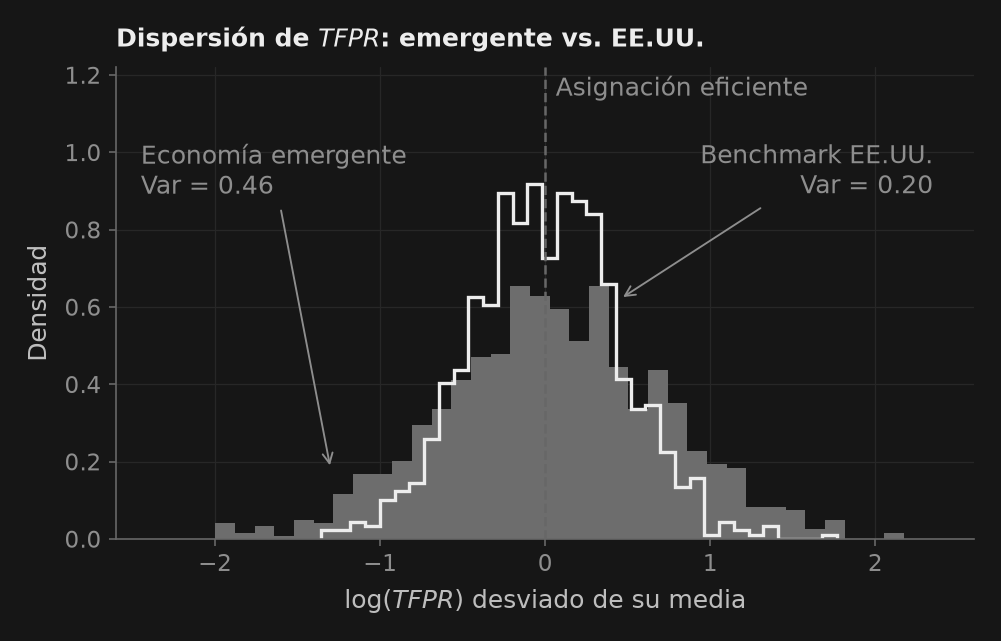

In [8]:
# Fijar semilla aleatoria para reproducibilidad científica
np.random.seed(42)
N = 1000
sigma_elasticity = 3.0

# 1. Calibrar benchmarks empíricos de dispersión de TFPR (Hsieh-Klenow 2009, Tabla II)
std_tfpr_us = 0.45                                         # Benchmark manufacturero de EE.UU.
std_tfpr_dev = 0.68                                        # Benchmark de economía emergente (China / India)

# 2. Simular sección cruzada de empresas
log_tfpq = np.random.normal(0.0, 0.80, N)                  # Productividad física log(TFPQ)
log_tfpr_dev = np.random.normal(0.0, std_tfpr_dev, N)      # Productividad de ingreso con distorsiones
log_tfpr_us = np.random.normal(0.0, std_tfpr_us, N)        # Productividad de ingreso benchmark

var_dev = float(np.var(log_tfpr_dev))
var_us = float(np.var(log_tfpr_us))

# 3. Calcular ganancias contrafactuales de PTF agregada
tfp_gain_to_us = np.exp(0.5 * sigma_elasticity * (var_dev - var_us)) - 1.0
tfp_gain_to_efficient = np.exp(0.5 * sigma_elasticity * var_dev) - 1.0

print(f"Var(log TFPR) empírica: Emergente = {var_dev:.4f} vs Benchmark EE.UU. = {var_us:.4f}")
print(f"Ganancia contrafactual de PTF al cerrar la brecha con EE.UU.: {tfp_gain_to_us * 100:.1f}%")
print(f"Ganancia potencial de PTF bajo eficiencia asignativa plena: {tfp_gain_to_efficient * 100:.1f}%")

# 4. Aserciones objetivas de verificación
assert var_dev > var_us, "La economía emergente debe presentar mayor dispersión de TFPR"
assert 0.35 <= tfp_gain_to_us <= 0.60, f"Ganancia esperada en [35%, 60%], se obtuvo {tfp_gain_to_us*100:.1f}%"
assert tfp_gain_to_efficient > 0.80, f"Eficiencia total debe elevar la PTF > 80%, se obtuvo {tfp_gain_to_efficient*100:.1f}%"

# 5. Visualizar distribuciones empíricas de TFPR
fig, ax = _nbstyle.figura()
ax.hist(log_tfpr_dev, bins=35, density=True, color=_nbstyle.tono(0.45))
ax.hist(log_tfpr_us, bins=35, density=True, histtype="step", lw=1.6,
        color=_nbstyle.TINTA)
ax.axvline(0.0, color=_nbstyle.SPINE, linestyle="--", linewidth=1.2)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(0.0, 1.22)
ax.set_xlabel(r"$\log(TFPR)$ desviado de su media")
ax.set_ylabel("Densidad")
ax.set_title(r"Dispersión de $TFPR$: emergente vs. EE.UU.")
ax.annotate(f"Economía emergente\nVar = {var_dev:.2f}", xy=(-1.30, 0.18),
            xytext=(-2.45, 0.95), ha="left", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate(f"Benchmark EE.UU.\nVar = {var_us:.2f}", xy=(0.45, 0.62),
            xytext=(2.35, 0.95), ha="right", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("Asignación eficiente", xy=(0.0, 1.0), xycoords=("data", "axes fraction"),
            xytext=(5, -4), textcoords="offset points", ha="left", va="top",
            color=_nbstyle.NOTA)
plt.show()


### Síntesis Empírica: Eficiencia Asignativa, Empresas Zombis y el Enigma del Desarrollo Macroeconómico

Este contrafactual empírico esclarece por qué la asignación ineficiente de recursos es central para la macroeconomía contemporánea:

1. **Explicación de las Brechas de Ingreso entre Países**: Los modelos neoclásicos tradicionales tenían dificultades para explicar por qué las economías emergentes generan un producto por trabajador tan bajo a pesar de acumular importantes volúmenes de capital físico. Hsieh y Klenow (2009) demostraron que **entre el 30% y el 60% de la brecha de PTF agregada** entre países en desarrollo y Estados Unidos se explica por la mala asignación intra-sectorial del capital y el trabajo, y no por carencia de tecnología.
2. **Anatomía de las Cuñas de Distorsión**:
   - **Fricciones Financieras**: Sistemas bancarios estatales o créditos con subsidios dirigen fondos baratos a empresas poco productivas pero con influencia política, mientras que empresas privadas dinámicas pagan tasas prohibitivas.
   - **Distorsiones por Tamaño e Informalidad**: Umbrales regulatorios (como inspecciones laborales que se activan a partir de cierta cantidad de empleados o fiscalización tributaria a empresas registradas) incentivan a firmas productivas a mantenerse artificialmente pequeñas o en la informalidad.
   - **Conglomerados Zombis**: Marcos de insolvencia y quiebras deficientes impiden la liquidación de empresas crónicamente inviables, inmovilizando bienes raíces, maquinaria y mano de obra calificada.
3. **Conexión Curricular**: La dinámica y selección empresarial representan la contraparte de oferta a la heterogeneidad de riqueza de los hogares en modelos de **Aiyagari-Bewley** (`T06_A_wealth_inequality_es`) y a las fricciones de búsqueda en modelos de **Diamond-Mortensen-Pissarides** (`T08_A_labor_flows_es`).